# **PRAKTIKUM PERTEMUAN 12 DATA SCIENCE**

Nama : Ninis Indah Trisia

NIM : 250401020094

Kelas : IF405

In [27]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [28]:
import os

os.environ["PYTHONWARNINGS"] = "ignore"

import warnings

warnings.simplefilter("ignore")
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="jupyter_client"
)

### Langkah 1: Generate & Eksplorasi Dataset Transaksi

Contoh transaksi:
[[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]

Jumlah transaksi: 50


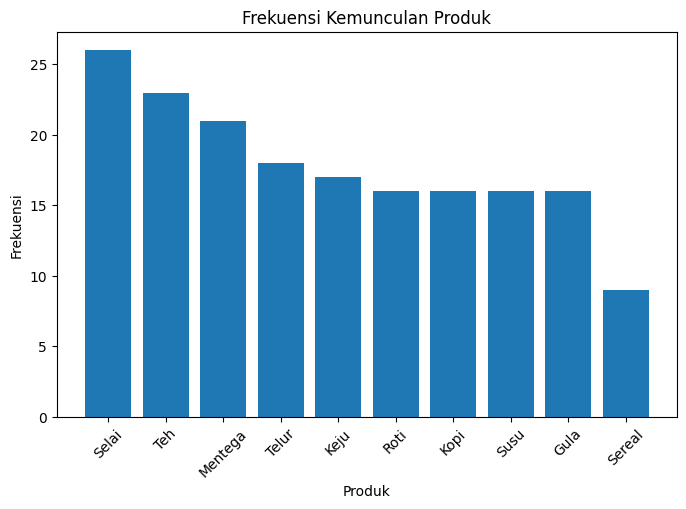

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)

produk = [
    "Roti", "Selai", "Susu", "Sereal", "Telur",
    "Keju", "Kopi", "Gula", "Teh", "Mentega"
]

transaksi = []

for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(
        list(np.random.choice(produk, n_item, replace=False))
    )

for i in range(20):
    if "Roti" in transaksi[i] and "Selai" not in transaksi[i]:
        transaksi[i].append("Selai")

print("Contoh transaksi:")
print(transaksi[:3])

print("\nJumlah transaksi:", len(transaksi))

counter = Counter()

for item in transaksi:
    counter.update(item)

frekuensi = pd.DataFrame({
    "Produk": counter.keys(),
    "Frekuensi": counter.values()
}).sort_values("Frekuensi", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(frekuensi["Produk"], frekuensi["Frekuensi"])
plt.title("Frekuensi Kemunculan Produk")
plt.xlabel("Produk")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.show()

Pada langkah pertama dibuat dataset transaksi belanja secara sintetis menggunakan Python. Setiap transaksi berisi beberapa produk yang dipilih secara acak dari daftar produk yang telah ditentukan, seperti Roti, Susu, Telur, Kopi, Gula, dan produk lainnya. Dataset kemudian disimpan dalam bentuk DataFrame agar lebih mudah diproses.

Selanjutnya dilakukan eksplorasi data untuk memahami karakteristik dataset. Jumlah transaksi dihitung, kemudian frekuensi kemunculan setiap produk dihitung menggunakan proses iterasi pada seluruh transaksi. Hasil perhitungan ditampilkan dalam bentuk tabel dan divisualisasikan menggunakan diagram batang (bar chart). Visualisasi ini membantu mengidentifikasi produk yang paling sering dibeli sehingga memberikan gambaran awal mengenai pola transaksi pelanggan.

### Langkah 2: One-Hot Encoding Transaksi

In [22]:
!pip -q install mlxtend

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

te_ary = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(
    te_ary,
    columns=te.columns_
)

print(df.head())

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


Karena algoritma Apriori tidak dapat langsung memproses data berbentuk daftar produk, maka dilakukan proses One-Hot Encoding. Pada tahap ini setiap nama produk diubah menjadi satu kolom tersendiri. Nilai pada setiap kolom akan bernilai True (1) apabila produk tersebut terdapat pada transaksi, dan False (0) apabila tidak ada.

Hasil transformasi berupa matriks biner dengan jumlah baris sesuai jumlah transaksi dan jumlah kolom sesuai banyaknya produk. Format data ini menjadi input utama bagi algoritma Apriori untuk mencari kombinasi produk yang sering muncul secara bersamaan dalam transaksi.

### Langkah 3: Cari Frequent Itemset dengan Apriori

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan
    support      itemsets
5      0.52       (Selai)
8      0.46         (Teh)
3      0.42     (Mentega)
9      0.36       (Telur)
1      0.34        (Keju)
0      0.32        (Gula)
2      0.32        (Kopi)
4      0.32        (Roti)
7      0.32        (Susu)
36     0.24  (Teh, Selai)


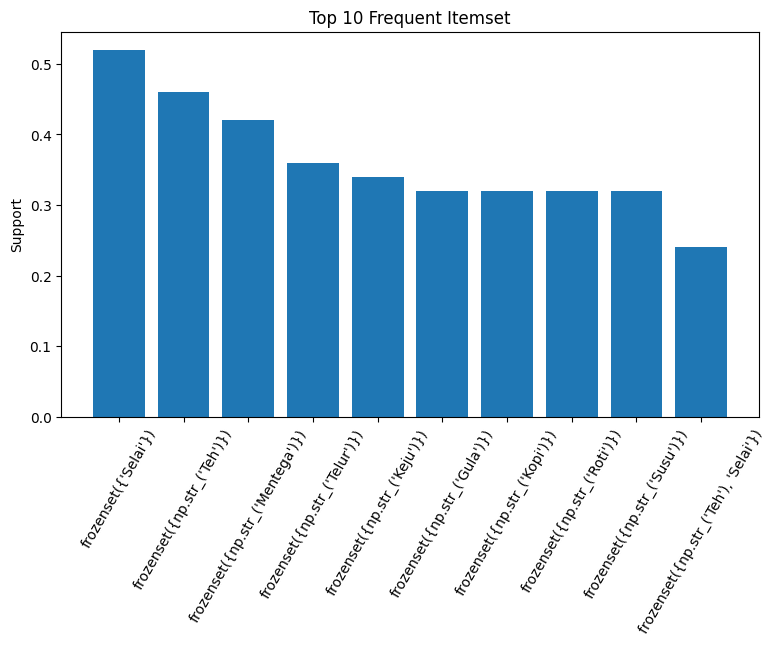

In [23]:
from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.1, 0.2]:

    freq = apriori(
        df,
        min_support=ms,
        use_colnames=True
    )

    print(f"min_support={ms}: {len(freq)} itemset ditemukan")

freq_items = apriori(
    df,
    min_support=0.1,
    use_colnames=True
)

freq_items = freq_items.sort_values(
    "support",
    ascending=False
)

print(freq_items.head(10))

plt.figure(figsize=(9,5))

plt.bar(
    freq_items.head(10)["itemsets"].astype(str),
    freq_items.head(10)["support"]
)

plt.xticks(rotation=60)
plt.ylabel("Support")
plt.title("Top 10 Frequent Itemset")
plt.show()

Setelah data berhasil diubah ke format biner, langkah berikutnya adalah menjalankan algoritma Apriori untuk menemukan frequent itemset, yaitu kombinasi produk yang sering muncul dalam transaksi.

Proses dilakukan menggunakan beberapa nilai minimum support, misalnya 0,05, 0,10, dan 0,15. Nilai support menunjukkan persentase minimum kemunculan suatu kombinasi produk terhadap seluruh transaksi. Semakin kecil nilai support, semakin banyak kombinasi produk yang dapat ditemukan, sedangkan semakin besar nilai support, kombinasi yang dihasilkan akan lebih sedikit tetapi lebih sering muncul.

Hasil frequent itemset kemudian diurutkan berdasarkan nilai support tertinggi dan divisualisasikan menggunakan diagram batang sehingga dapat diketahui kombinasi produk mana yang paling sering dibeli secara bersamaan oleh pelanggan.

### Langkah 4: Bentuk & Saring Aturan Asosiasi

         antecedents consequents  support  confidence      lift
8        (Teh, Keju)     (Telur)     0.12    0.857143  2.380952
15  (Mentega, Selai)      (Kopi)     0.10    0.625000  1.953125
11      (Roti, Gula)     (Selai)     0.10    1.000000  1.923077
7           (Sereal)   (Mentega)     0.14    0.777778  1.851852
9       (Teh, Telur)      (Keju)     0.12    0.600000  1.764706
14     (Kopi, Selai)   (Mentega)     0.10    0.714286  1.700680
10     (Keju, Telur)       (Teh)     0.12    0.750000  1.630435
12     (Selai, Gula)      (Roti)     0.10    0.500000  1.562500
13   (Kopi, Mentega)     (Selai)     0.10    0.714286  1.373626
1             (Roti)     (Selai)     0.22    0.687500  1.322115


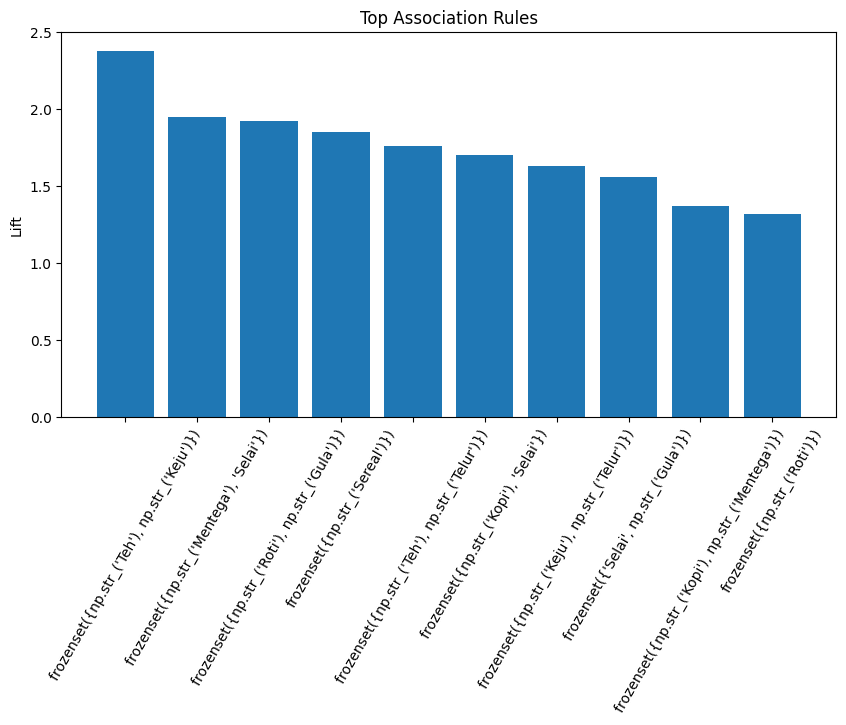

In [24]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.5
)

rules = rules[
    rules["lift"] > 1
].sort_values(
    "lift",
    ascending=False
)

print(
    rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(10)
)

top_rules = rules.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_rules["antecedents"].astype(str),
    top_rules["lift"]
)

plt.xticks(rotation=60)
plt.ylabel("Lift")
plt.title("Top Association Rules")
plt.show()

Frequent itemset yang telah diperoleh kemudian digunakan untuk membentuk Association Rules atau aturan asosiasi. Aturan ini menjelaskan hubungan antara satu produk dengan produk lainnya, misalnya pelanggan yang membeli Roti juga cenderung membeli Susu.

Pada tahap ini dihitung beberapa metrik penting, yaitu:

* Support, untuk mengetahui seberapa sering aturan tersebut muncul pada seluruh transaksi.
* Confidence, untuk mengukur tingkat kemungkinan pelanggan membeli produk tujuan setelah membeli produk awal.
* Lift, untuk mengetahui seberapa kuat hubungan kedua produk dibandingkan jika keduanya muncul secara acak.

Agar aturan yang dihasilkan benar-benar bermakna, hanya aturan dengan nilai confidence sesuai batas minimum dan lift lebih dari 1 yang ditampilkan. Selanjutnya aturan tersebut diurutkan berdasarkan nilai lift tertinggi sehingga hubungan antarproduk yang paling kuat dapat dianalisis.

### Langkah 5: Rekomender Sederhana dengan Content-Based Filtering

Mirip dengan Roti:
['Selai', 'Sereal', 'Susu']


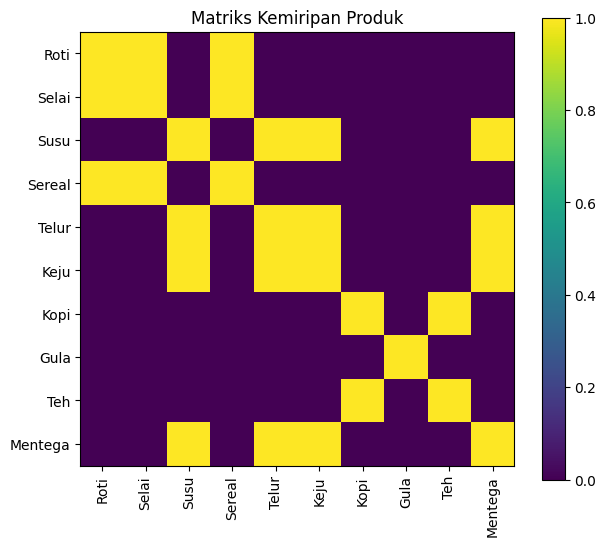

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    "produk": produk,
    "kategori": [
        "Bakery","Bakery","Dairy","Bakery","Dairy",
        "Dairy","Minuman","Bumbu","Minuman","Dairy"
    ]
})

fitur = pd.get_dummies(katalog["kategori"])

sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(nama_produk, top_n=3):

    idx = katalog.index[
        katalog["produk"] == nama_produk
    ][0]

    skor = list(enumerate(sim_matrix[idx]))

    skor = sorted(
        skor,
        key=lambda x: x[1],
        reverse=True
    )

    skor = [
        s for s in skor
        if s[0] != idx
    ][:top_n]

    return katalog.iloc[
        [i for i, _ in skor]
    ]["produk"].tolist()

print("Mirip dengan Roti:")
print(rekomendasi_serupa("Roti"))

plt.figure(figsize=(7,6))

plt.imshow(sim_matrix)

plt.colorbar()

plt.xticks(range(len(produk)), produk, rotation=90)
plt.yticks(range(len(produk)), produk)

plt.title("Matriks Kemiripan Produk")

plt.show()

Selain menggunakan Association Rules, praktikum juga membuat sistem rekomendasi sederhana menggunakan metode Content-Based Filtering. Metode ini tidak melihat pola pembelian pelanggan, melainkan melihat kemiripan karakteristik antarproduk.

Setiap produk terlebih dahulu diberi atribut atau kategori, kemudian atribut tersebut diubah menjadi representasi numerik. Setelah itu dihitung tingkat kemiripan antarproduk menggunakan Cosine Similarity. Nilai similarity yang semakin mendekati 1 menunjukkan bahwa kedua produk memiliki karakteristik yang semakin mirip.

Ketika pengguna memilih sebuah produk, sistem akan mencari beberapa produk lain yang memiliki nilai similarity tertinggi. Dengan demikian, rekomendasi diberikan berdasarkan kemiripan karakteristik produk, bukan berdasarkan riwayat transaksi pelanggan.

### Langkah 6: Bandingkan Kedua Pendekatan

In [26]:
produk_target = "Roti"

rules_terkait = rules[
    rules["antecedents"].apply(
        lambda x: produk_target in x
    )
]

print("Rekomendasi dari Association Rules")
print(
    rules_terkait[
        ["consequents","lift"]
    ].head()
)

print()

print("Rekomendasi dari Content-Based")
print(
    rekomendasi_serupa(produk_target)
)

Rekomendasi dari Association Rules
   consequents      lift
11     (Selai)  1.923077
1      (Selai)  1.322115

Rekomendasi dari Content-Based
['Selai', 'Sereal', 'Susu']


ada langkah terakhir dilakukan perbandingan antara hasil rekomendasi dari Association Rules dan Content-Based Filtering. Tujuannya adalah memahami perbedaan cara kerja kedua metode serta mengetahui kondisi yang sesuai untuk masing-masing pendekatan.

Association Rules menghasilkan rekomendasi berdasarkan kebiasaan pelanggan dalam membeli produk secara bersamaan. Oleh karena itu, metode ini sangat bergantung pada banyaknya data transaksi yang tersedia. Sebaliknya, Content-Based Filtering memberikan rekomendasi berdasarkan kemiripan karakteristik atau atribut produk, sehingga tetap dapat digunakan meskipun belum tersedia banyak data transaksi.

# Kesimpulan
Berdasarkan praktikum yang telah dilakukan dari langkah 1 hingga langkah 6, dapat disimpulkan bahwa proses pembuatan sistem rekomendasi dimulai dari penyusunan dan eksplorasi dataset transaksi, kemudian mengubah data ke dalam format one-hot encoding agar dapat diproses oleh algoritma Apriori. Selanjutnya, algoritma Apriori berhasil menemukan frequent itemset dan menghasilkan association rules yang menunjukkan hubungan antarproduk berdasarkan pola pembelian pelanggan. Selain itu, metode Content-Based Filtering mampu memberikan rekomendasi berdasarkan kemiripan karakteristik produk menggunakan perhitungan Cosine Similarity.

Hasil praktikum menunjukkan bahwa kedua metode memiliki cara kerja dan keunggulan yang berbeda. Association Rules lebih efektif untuk menemukan produk yang sering dibeli secara bersamaan berdasarkan riwayat transaksi, sedangkan Content-Based Filtering lebih sesuai untuk merekomendasikan produk yang memiliki karakteristik serupa meskipun belum memiliki banyak data transaksi. Dengan memahami kedua pendekatan tersebut, dapat diketahui bahwa pemilihan metode rekomendasi harus disesuaikan dengan jenis data yang tersedia dan tujuan sistem yang akan dibangun.